Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


 Load Dataset and Images from Drive

In [ ]:
import os
import pandas as pd

base_dir = '/content/drive/MyDrive/laby'
excel_path = os.path.join(base_dir, 'Data-Laby 5-12.xlsx')
image_dir = os.path.join(base_dir, 'images')

# Load the dataset
df = pd.read_excel(excel_path)

# Add consistent image_id (1.jpg, 2.jpg, ...)
df['image_id'] = df.index + 1
df['image_id'] = df['image_id'].astype(str) + '.jpg'

# Keep only what's needed
df = df[['image_id', 'LC', 'MD']]
df['image_path'] = df['image_id'].apply(lambda x: os.path.join(image_dir, x))


Preprocess Images and Labels

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.preprocessing.image import load_img, img_to_array

IMG_SIZE = 224

def preprocess_image(path):
    img = load_img(path, target_size=(IMG_SIZE, IMG_SIZE))
    img = img_to_array(img) / 255.0  # Normalize
    return img

# Load all images
X = np.array([preprocess_image(path) for path in df['image_path']])

# Labels
y = df[['LC', 'MD']].values

# Normalize targets
scaler = MinMaxScaler()
y_scaled = scaler.fit_transform(y)

# Train/test split
X_train, X_test, y_train_scaled, y_test_scaled, df_train, df_test = train_test_split(
    X, y_scaled, df, test_size=5, random_state=42
)


# **Train Models**

We’ll train:

🎯 MobileNetV2 for LC

🎯 CNN for MD

Each model will be trained on a single target from y_train_scaled:

LC = y_train_scaled[:, 0]

MD = y_train_scaled[:, 1]

MobileNetV2 Model for LC

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense

# Build MobileNetV2 for LC
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False

inputs = Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(64, activation='relu')(x)
output = Dense(1, activation='linear')(x)

mobilenet_model = Model(inputs, output)
mobilenet_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train
mobilenet_model.fit(
    X_train, y_train_scaled[:, 0],  # LC only
    validation_data=(X_test, y_test_scaled[:, 0]),
    epochs=50,
    batch_size=4
)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 469ms/step - loss: 1.3836 - mae: 1.0033 - val_loss: 0.1938 - val_mae: 0.3585
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - loss: 0.4498 - mae: 0.5902 - val_loss: 0.2667 - val_mae: 0.4506
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - loss: 0.1795 - mae: 0.3260 - val_loss: 0.3484 - val_mae: 0.4989
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - loss: 0.2958 - mae: 0.4416 - val_loss: 0.1155 - val_mae: 0.2694
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - loss: 0.0777 - mae: 0.2537 - val_loss: 0.0630 - val_mae: 0.1887
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - loss: 0.0448 - mae: 0.1738 - val_loss: 0.0694 - val_mae: 0.2455
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - loss: 0.0323 - mae: 0.1560 - val_loss: 0.0688 - val_mae: 0.1736
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - loss: 0.0332 - mae: 0.1496 - val_loss: 0.0417 - val_mae: 0.1402
Epoch 9/50
4/4 ━━━━━━━━

 CNN Model for MD

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dropout

cnn_model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224, 224, 3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='linear')
])

cnn_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

cnn_model.fit(
    X_train, y_train_scaled[:, 1],  # MD only
    validation_data=(X_test, y_test_scaled[:, 1]),
    epochs=50,
    batch_size=4
)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 328ms/step - loss: 765.0004 - mae: 15.9606 - val_loss: 0.4011 - val_mae: 0.5610
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 279ms/step - loss: 0.3429 - mae: 0.4954 - val_loss: 0.0875 - val_mae: 0.2802
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 270ms/step - loss: 0.2837 - mae: 0.4511 - val_loss: 0.1798 - val_mae: 0.3273
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 269ms/step - loss: 0.2628 - mae: 0.3770 - val_loss: 0.4045 - val_mae: 0.5640
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 291ms/step - loss: 0.3088 - mae: 0.4748 - val_loss: 0.0878 - val_mae: 0.2806
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 376ms/step - loss: 0.2979 - mae: 0.4648 - val_loss: 0.1794 - val_mae: 0.3264
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 257ms/step - loss: 0.3421 - mae: 0.5250 - val_loss: 0.1757 - val_mae: 0.3225
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 235ms/step - loss: 0.3077 - mae: 0.4437 - val_loss: 0.0856 - val_mae: 0.2737
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 236ms/step - loss: 0.2688 - ma

# **Predict on Test Set, Inverse Scale, and Export to CSV**

Predict LC using mobilenet_model

Predict MD using cnn_model

In [ ]:
# Predict (scaled)
lc_pred_scaled = mobilenet_model.predict(X_test)
md_pred_scaled = cnn_model.predict(X_test)

# Stack predictions for inverse scaling
pred_combined_scaled = np.hstack([lc_pred_scaled, md_pred_scaled])
pred_combined = scaler.inverse_transform(pred_combined_scaled)

# Also inverse scale true values
y_true = scaler.inverse_transform(y_test_scaled)

# Create final DataFrame
df_results = pd.DataFrame({
    "Image ID": df_test['image_id'].str.replace(".jpg", "", regex=False).astype(int),
    "Real LC": y_true[:, 0],
    "Real MD": y_true[:, 1],
    "Predicted LC (MobileNetV2)": pred_combined[:, 0],
    "Predicted MD (CNN)": pred_combined[:, 1]
})

# Sort by image ID for clarity
df_results = df_results.sort_values(by="Image ID")

# Save to CSV
output_path = "/content/drive/MyDrive/laby/lc_md_predictions_hybrid.csv"
df_results.to_csv(output_path, index=False)

print("✅ Results saved to:", output_path)
df_results


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
✅ Results saved to: /content/drive/MyDrive/laby/lc_md_predictions_hybrid.csv


,Image ID,Real LC,Real MD,Predicted LC (MobileNetV2),Predicted MD (CNN)
0,1,7.0,5.0,5.533447,1.928198
1,2,8.0,2.0,7.557386,1.885547
8,9,3.0,2.0,7.092279,1.949168
15,16,0.0,1.0,0.134574,1.837654
17,18,6.0,4.0,4.951452,1.862698


Plotting the results

In [ ]:
# Predict LC on all 20 images
lc_all_scaled = mobilenet_model.predict(X)
md_all_scaled = cnn_model.predict(X)

# Inverse scale
combined_all_scaled = np.hstack([lc_all_scaled, md_all_scaled])
combined_all = scaler.inverse_transform(combined_all_scaled)

# Build full result DataFrame
df_all_results = pd.DataFrame({
    "Image ID": df["image_id"].str.replace(".jpg", "", regex=False).astype(int),
    "Real LC": df["LC"],
    "Real MD": df["MD"],
    "Predicted LC (MobileNetV2)": combined_all[:, 0],
    "Predicted MD (CNN)": combined_all[:, 1]
})

# Sort
df_all_results = df_all_results.sort_values("Image ID")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step


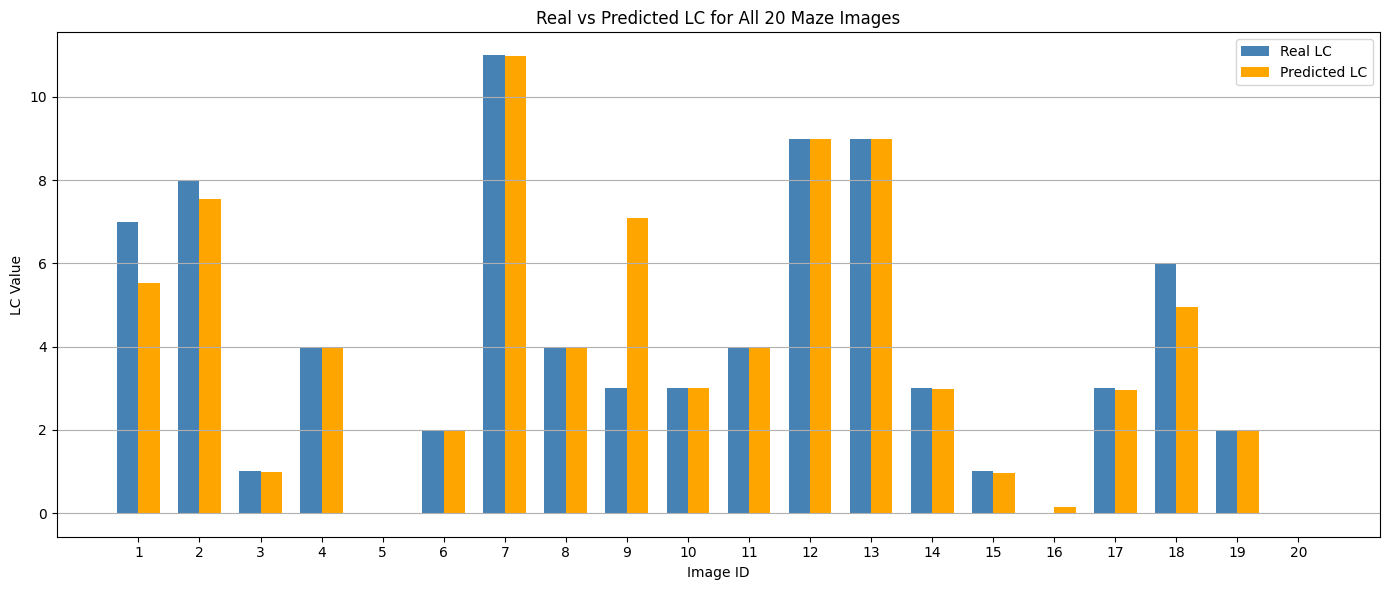

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Bar plot: Real vs Predicted LC
image_ids = df_all_results["Image ID"].astype(str)
real_lc = df_all_results["Real LC"]
pred_lc = df_all_results["Predicted LC (MobileNetV2)"]

x = np.arange(len(image_ids))
width = 0.35

plt.figure(figsize=(14, 6))
plt.bar(x - width/2, real_lc, width, label='Real LC', color='steelblue')
plt.bar(x + width/2, pred_lc, width, label='Predicted LC', color='orange')

plt.xlabel("Image ID")
plt.ylabel("LC Value")
plt.title("Real vs Predicted LC for All 20 Maze Images")
plt.xticks(x, image_ids)
plt.legend()
plt.grid(axis='y')
plt.tight_layout()
plt.show()


Plots for MD now

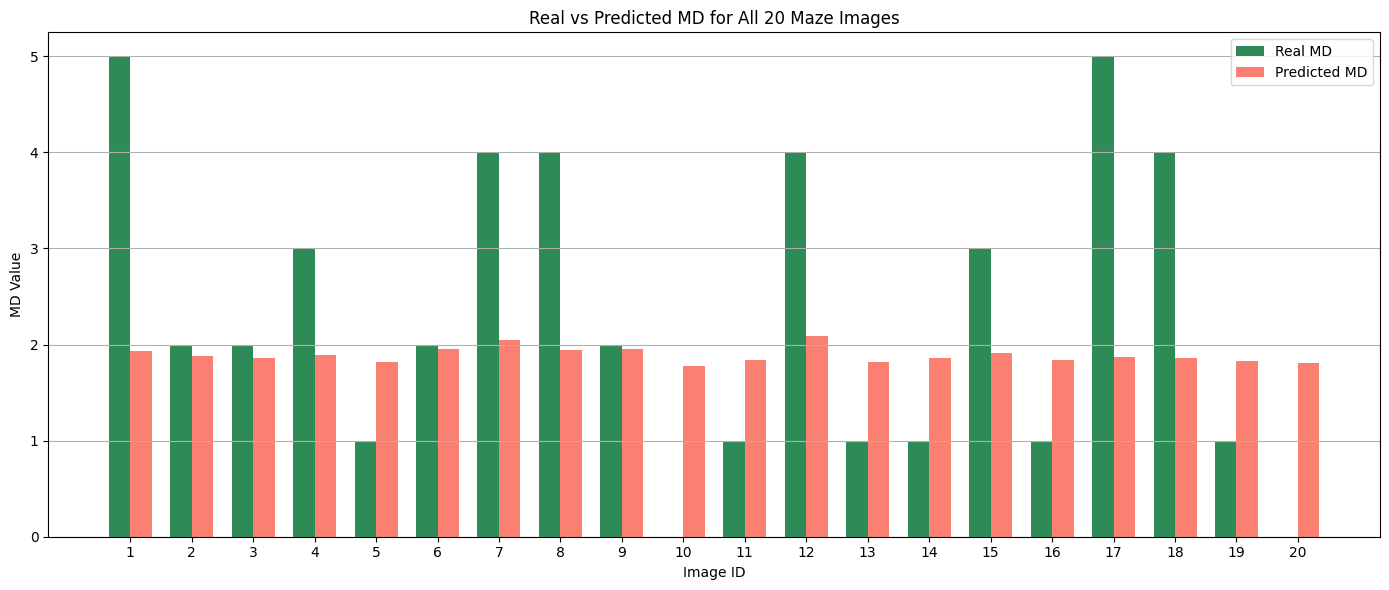

In [ ]:
# Bar plot: Real vs Predicted MD
image_ids = df_all_results["Image ID"].astype(str)
real_md = df_all_results["Real MD"]
pred_md = df_all_results["Predicted MD (CNN)"]

x = np.arange(len(image_ids))
width = 0.35

plt.figure(figsize=(14, 6))
plt.bar(x - width/2, real_md, width, label='Real MD', color='seagreen')
plt.bar(x + width/2, pred_md, width, label='Predicted MD', color='salmon')

plt.xlabel("Image ID")
plt.ylabel("MD Value")
plt.title("Real vs Predicted MD for All 20 Maze Images")
plt.xticks(x, image_ids)
plt.legend()
plt.grid(axis='y')
plt.tight_layout()
plt.show()
